<a href="https://colab.research.google.com/github/Akanksha-Bhargavi/Akanksha-Bhargavi/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import torch
import torch

# Setup device agnostic code


# Setup random seed
RANDOM_SEED = 42

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors.
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

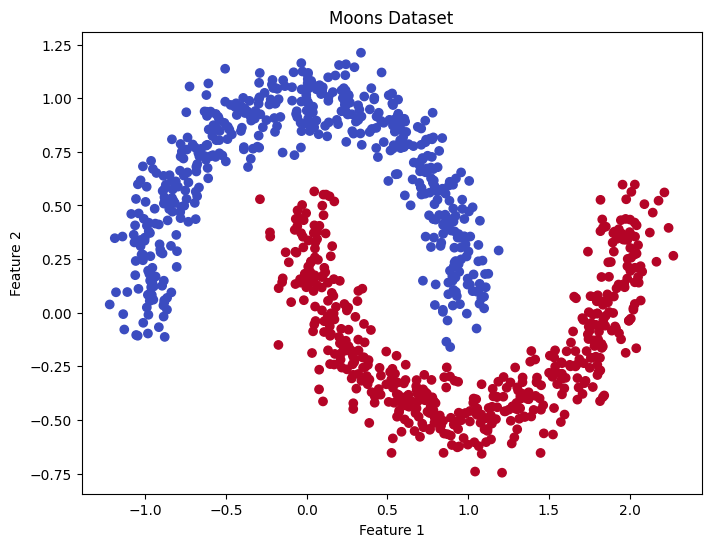

Training data shape: torch.Size([800, 2]), Training labels shape: torch.Size([800])
Test data shape: torch.Size([200, 2]), Test labels shape: torch.Size([200])


In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Step 1: Create the dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Step 2: Convert to DataFrame
data = pd.DataFrame(data=X, columns=['feature_1', 'feature_2'])
data['label'] = y

# Step 3: Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(data['feature_1'], data['feature_2'], c=data['label'], cmap='coolwarm')
plt.title('Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Step 4: Convert data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Step 5: Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")


## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [6]:
from torch import nn
class MoonModelV0(nn.Module):
    def __init__(self):
        super(MoonModelV0, self).__init__()
        self.hidden1 = nn.Linear(2, 16)
        self.hidden2 = nn.Linear(16, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = torch.sigmoid(self.output(x))
        return x

model = MoonModelV0()
print(model)

MoonModelV0(
  (hidden1): Linear(in_features=2, out_features=16, bias=True)
  (hidden2): Linear(in_features=16, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [7]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [8]:
model.eval()
with torch.inference_mode():
    sample_logits = model(X_test[:5]).squeeze()
    sample_probs = torch.sigmoid(sample_logits)
    sample_labels = torch.round(sample_probs)

print("\nLogits:")
print(sample_logits)

print("\nPrediction probabilities:")
print(sample_probs)

print("\nPrediction labels:")
print(sample_labels)

print("Training complete!")


Logits:
tensor([0.5038, 0.5147, 0.5033, 0.5220, 0.5031])

Prediction probabilities:
tensor([0.6234, 0.6259, 0.6232, 0.6276, 0.6232])

Prediction labels:
tensor([1., 1., 1., 1., 1.])
Training complete!


In [10]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
#!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
# acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
# acc_fn

acc_fn = Accuracy(task="binary")

In [11]:
torch.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    # Training
    model.train()

    # Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(y_logits)

    # Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_pred, y_train.int())

    # Zero gradients, backpropagation, and optimizer step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(test_logits)

        test_loss = loss_fn(test_logits, y_test)
        test_acc = acc_fn(test_pred, y_test.int())

    # Output progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss:.4f} | Train Acc: {acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Epoch 000 | Train Loss: 0.6998 | Train Acc: 0.5587 | Test Loss: 0.6844 | Test Acc: 0.6800
Epoch 010 | Train Loss: 0.4942 | Train Acc: 0.7937 | Test Loss: 0.4903 | Test Acc: 0.7600
Epoch 020 | Train Loss: 0.2977 | Train Acc: 0.8450 | Test Loss: 0.2980 | Test Acc: 0.8400
Epoch 030 | Train Loss: 0.2171 | Train Acc: 0.9062 | Test Loss: 0.2008 | Test Acc: 0.9200
Epoch 040 | Train Loss: 0.1726 | Train Acc: 0.9250 | Test Loss: 0.1560 | Test Acc: 0.9250
Epoch 050 | Train Loss: 0.1238 | Train Acc: 0.9450 | Test Loss: 0.1122 | Test Acc: 0.9600
Epoch 060 | Train Loss: 0.0795 | Train Acc: 0.9775 | Test Loss: 0.0708 | Test Acc: 0.9850
Epoch 070 | Train Loss: 0.0466 | Train Acc: 0.9912 | Test Loss: 0.0395 | Test Acc: 0.9950
Epoch 080 | Train Loss: 0.0276 | Train Acc: 0.9962 | Test Loss: 0.0222 | Test Acc: 1.0000
Epoch 090 | Train Loss: 0.0183 | Train Acc: 0.9962 | Test Loss: 0.0138 | Test Acc: 1.0000
Epoch 100 | Train Loss: 0.0135 | Train Acc: 0.9975 | Test Loss: 0.0098 | Test Acc: 1.0000
Epoch 110 

## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [12]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

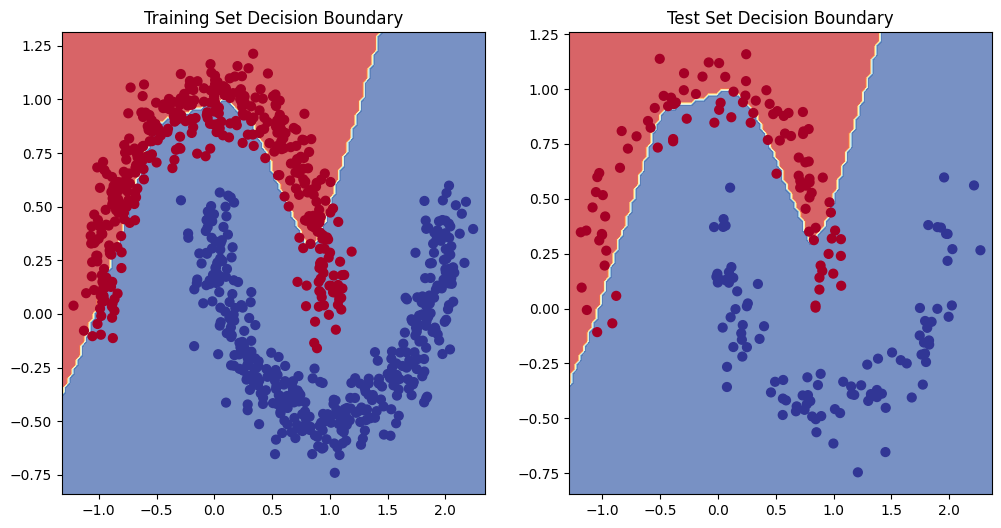

In [13]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))

# Plot decision boundary for training set
plt.subplot(1, 2, 1)
plot_decision_boundary(model, X_train, y_train)
plt.title("Training Set Decision Boundary")

# Plot decision boundary for test set
plt.subplot(1, 2, 2)
plot_decision_boundary(model, X_test, y_test)
plt.title("Test Set Decision Boundary")

# Display the plot
plt.show()


## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

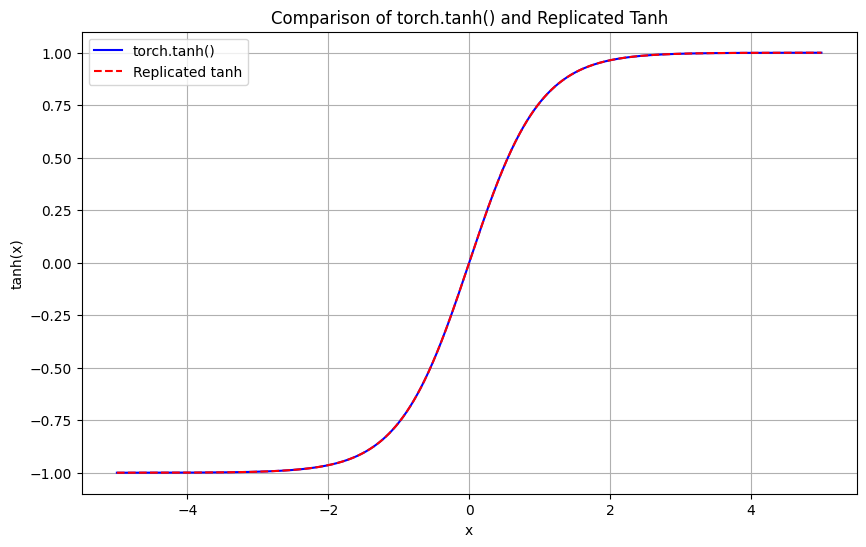

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a straight line tensor (range of values)
x = torch.linspace(-5, 5, 1000)

# Step 2: Apply torch.tanh() on the tensor
y_tanh = torch.tanh(x)

# Step 3: Manually replicate the Tanh function
y_tanh_manual = (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

# Step 4: Plot both the torch.tanh() and manually replicated tanh
plt.figure(figsize=(10, 6))
plt.plot(x.numpy(), y_tanh.numpy(), label='torch.tanh()', color='blue')
plt.plot(x.numpy(), y_tanh_manual.numpy(), label='Replicated tanh', linestyle='dashed', color='red')
plt.title("Comparison of torch.tanh() and Replicated Tanh")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.legend()
plt.grid(True)
plt.show()


## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

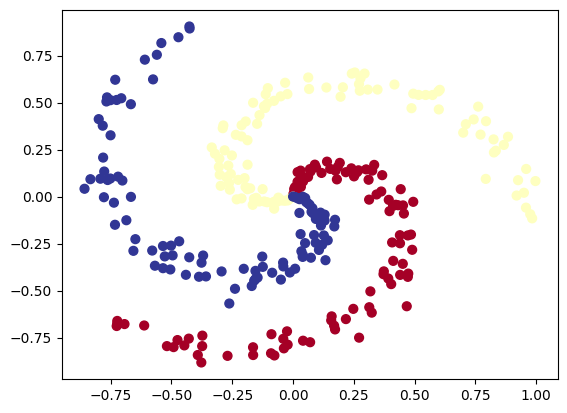

In [20]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Function to create a spiral dataset
def create_spirals(npoints, noise=0.1):
    N = 100
    D = 2
    K = 3
    X = np.zeros((N * K, D))
    y = np.zeros(N * K, dtype='uint8')

    for j in range(K):
        ix = range(N * j, N * (j + 1))
        r = np.linspace(0.0, 1, N)  # radius
        t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * noise  # theta
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j

    return X, y

# Create dataset
X, y = create_spirals(300, noise=0.2)

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()


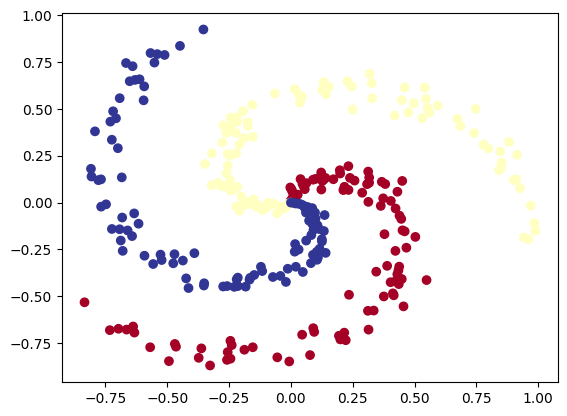

Epoch 000 | Train Loss: 1.1133 | Test Loss: 1.0913 | Test Accuracy: 0.4333
Epoch 100 | Train Loss: 0.7270 | Test Loss: 0.7479 | Test Accuracy: 0.4833
Epoch 200 | Train Loss: 0.6074 | Test Loss: 0.6289 | Test Accuracy: 0.6000
Epoch 300 | Train Loss: 0.5012 | Test Loss: 0.5155 | Test Accuracy: 0.7000
Epoch 400 | Train Loss: 0.4089 | Test Loss: 0.4151 | Test Accuracy: 0.8333
Epoch 500 | Train Loss: 0.3387 | Test Loss: 0.3389 | Test Accuracy: 0.8667
Epoch 600 | Train Loss: 0.2853 | Test Loss: 0.2831 | Test Accuracy: 0.9000
Epoch 700 | Train Loss: 0.2451 | Test Loss: 0.2413 | Test Accuracy: 0.9167
Epoch 800 | Train Loss: 0.2143 | Test Loss: 0.2100 | Test Accuracy: 0.9167
Epoch 900 | Train Loss: 0.1897 | Test Loss: 0.1841 | Test Accuracy: 0.9167


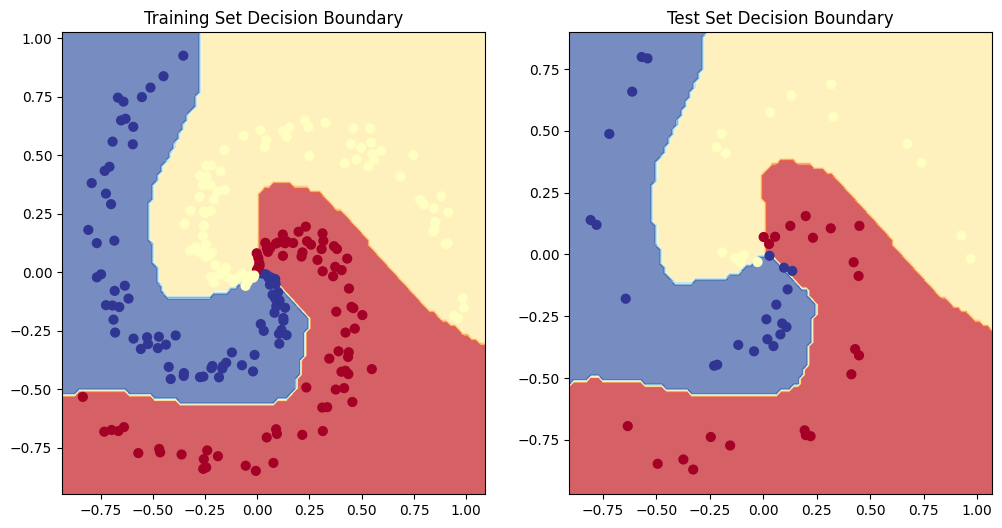

In [22]:
X, y = create_spirals(300, noise=0.2)

# Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).long()


X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

#Define the model
class SpiralModel(nn.Module):
    def __init__(self):
        super(SpiralModel, self).__init__()
        self.layer1 = nn.Linear(2, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.layer2(x)
        return x

# Instantiate the model and move it to the device
model = SpiralModel().to(device)

#  Set up the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Initialize accuracy metric
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device)

#  Training loop
epochs = 1000
for epoch in range(epochs):
    model.train()

    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = loss_fn(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing phase
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = test_logits.argmax(dim=1)
        test_acc = acc_fn(test_pred, y_test)

    # Print progress every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} | Test Accuracy: {test_acc.item():.4f}")

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))

# Training set decision boundary
plt.subplot(1, 2, 1)
plot_decision_boundary(model, X_train, y_train)
plt.title("Training Set Decision Boundary")

# Test set decision boundary
plt.subplot(1, 2, 2)
plot_decision_boundary(model, X_test, y_test)
plt.title("Test Set Decision Boundary")

plt.show()